# Project: Movie Recommendation System
- Objective

- Recommend movies to users based on:

1. Content-Based Filtering
2. Collaborative Filtering
3. Matrix Factorization (SVD)

# Import Libraries

In [3]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

# unzip data

In [10]:
import zipfile
file = "ml-32m.zip"
with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Data extracted successfully.")

Data extracted successfully.


# 1: Load Data

In [11]:
import pandas as pd
import numpy as np

movies = pd.read_csv("data/ml-32m/movies.csv")
ratings = pd.read_csv("data/ml-32m/ratings.csv")
tags = pd.read_csv("data/ml-32m/tags.csv")
links = pd.read_csv("data/ml-32m/links.csv")

# Check Dataset

In [12]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [13]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [14]:
movies.shape
ratings.shape

(32000204, 4)

# 2: Exploratory Data Analysis

In [15]:
# Number of Movies
print("Movies:", movies.movieId.nunique())

Movies: 87585


In [16]:
# Number of Users
print("Users:", ratings.userId.nunique())

Users: 200948


In [17]:
# Numbers of Ratings
print("Ratings:", ratings.shape[0])

Ratings: 32000204


### Rating Distribution

C:\Users\vipul\AppData\Local\Temp\ipykernel_8524\50903847.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


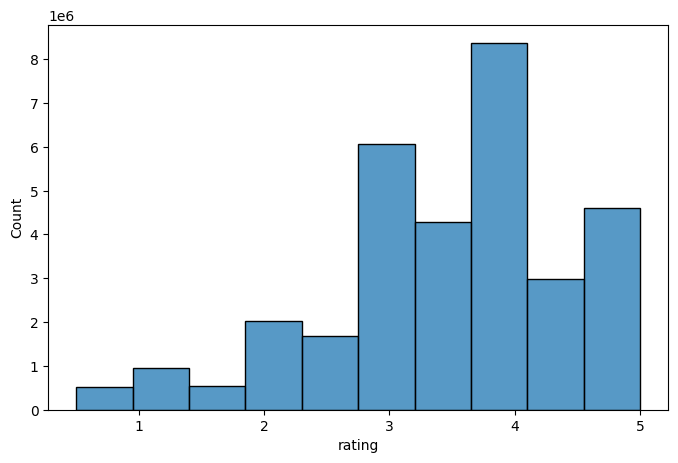

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    ratings["rating"],
    bins=10,
    palette="viridis",
    
)

plt.show()

### Most Rated Movies

In [20]:
movie_ratings = ratings.groupby(
    "movieId"
)["rating"].count()

movie_ratings.sort_values(
    ascending=False
).head(10)

movieId
318     102929
356     100296
296      98409
2571     93808
593      90330
260      85010
2959     77332
480      75233
527      73849
4993     73122
Name: rating, dtype: int64

# 3: Content-Based Recommendation

### Uses
- Genres
- Tags

- Merge Tags

In [23]:
tags = tags.dropna(subset=['tag'])

movie_tags = (
    tags.groupby('movieId')['tag']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index()
)

- Merge With Movies

In [24]:
movies_cb = movies.merge(
    movie_tags,
    on="movieId",
    how="left"
)

- Create Features

In [25]:
movies_cb["tag"] = movies_cb[
    "tag"
].fillna("")

movies_cb["features"] = (
    movies_cb["genres"]
    + " "
    + movies_cb["tag"]
)

- Vectorization

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    movies_cb["features"]
)

- Cosine Similarity

In [33]:
from sklearn.metrics.pairwise import cosine_similarity


In [35]:
from sklearn.metrics.pairwise import linear_kernel

def recommend_movie(title, top_n=10):

    idx = indices[title]

    movie_vector = tfidf_matrix[idx]

    cosine_scores = linear_kernel(
        movie_vector,
        tfidf_matrix
    ).flatten()

    similar_indices = cosine_scores.argsort()[-top_n-1:-1][::-1]

    return movies_cb.iloc[
        similar_indices
    ][['title']]

- Recommendation Function

In [29]:
indices = pd.Series(
    movies_cb.index,
    index=movies_cb["title"]
)

In [30]:
def recommend_movie(movie_name):

    idx = indices[movie_name]

    scores = list(
        enumerate(
            cosine_sim[idx]
        )
    )

    scores = sorted(
        scores,
        key=lambda x:x[1],
        reverse=True
    )

    scores = scores[1:11]

    movie_indices = [
        i[0]
        for i in scores
    ]

    return movies_cb.iloc[
        movie_indices
    ][["title"]]

In [36]:
recommend_movie(
    "Toy Story (1995)"
)

,title
3021,Toy Story 2 (1999)
2264,"Bug's Life, A (1998)"
14815,Toy Story 3 (2010)
4781,"Monsters, Inc. (2001)"
39850,Finding Dory (2016)
6259,Finding Nemo (2003)
8248,"Incredibles, The (2004)"
26634,The Adventures of André and Wally B. (1984)
19879,Monsters University (2013)
18314,Knick Knack (1989)


# 4: Collaborative Filtering

In [37]:
# Create User-Movie Matrix
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

C:\Users\vipul\AppData\Local\Temp\ipykernel_8524\2364977695.py:2: PerformanceWarning: The following operation may generate 16966441536 cells in the resulting pandas object.
  user_movie_matrix = ratings.pivot_table(


MemoryError: Unable to allocate 126. GiB for an array with shape (200948, 84432) and data type float64

In [ ]:
# Fill Missing Values

user_movie_matrix = (
    user_movie_matrix.fillna(0)
)

In [38]:
# User Similarity
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(
    user_movie_matrix
)

NameError: name 'user_movie_matrix' is not defined

In [39]:
# Similar Users
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

NameError: name 'user_similarity' is not defined